# Optional Lab

In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
import utils

np.set_printoptions(precision=2)
tf.get_logger().setLevel("ERROR")
tf.autograph.set_verbosity(0)

In [6]:
data = np.loadtxt("data_w3_ex1.csv", delimiter=",")

x = data[:, 0]
y = data[:, 1]

x = np.expand_dims(x, axis=1)
y = np.expand_dims(y, axis=1)

print(f"The shape of x is {x.shape}")
print(f"The shape of y is {y.shape}")

The shape of x is (50, 1)
The shape of y is (50, 1)


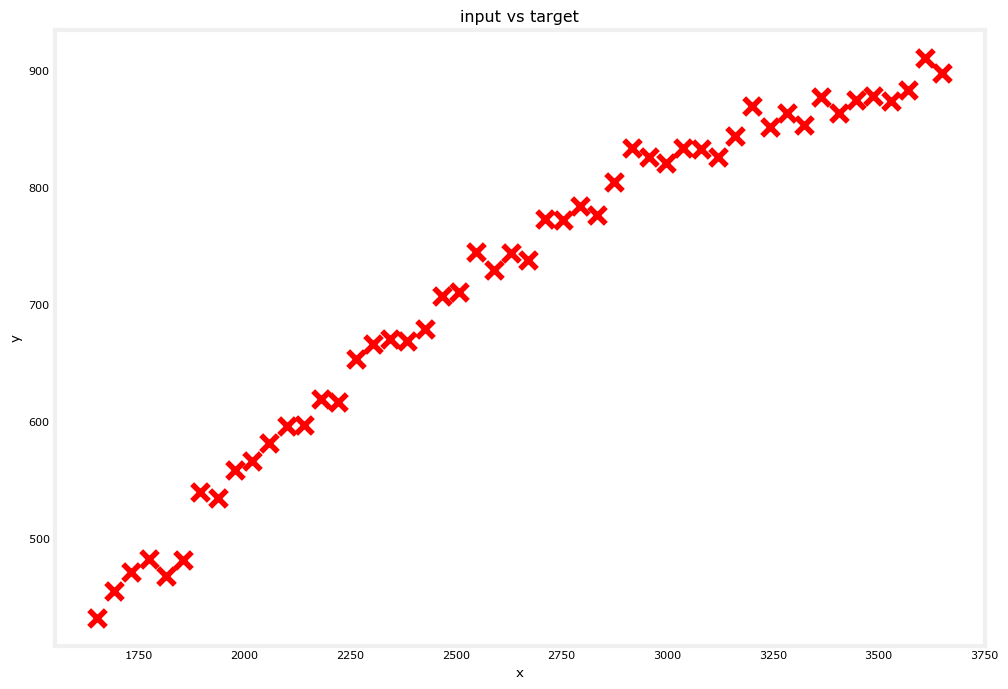

In [7]:
utils.plot_dataset(x=x, y=y, title="input vs target")

In [8]:
x_train, x_, y_train, y_ = train_test_split(x, y, test_size=0.40, random_state=1)
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.50, random_state=1)

del x_, y_

print(f"The shape of the training set (input) is {x_train.shape}")
print(f"The shape of the training set (target) is {y_train.shape}\n")
print(f"The shape of the cross-validation set (input) is {x_cv.shape}")
print(f"The shape of the cross-validation set (target) is {y_cv.shape}\n")
print(f"The shape of the test set (input) is {x_test.shape}")
print(f"The shape of the test set (target) is {y_test.shape}")

The shape of the training set (input) is (30, 1)
The shape of the training set (target) is (30, 1)

The shape of the cross-validation set (input) is (10, 1)
The shape of the cross-validation set (target) is (10, 1)

The shape of the test set (input) is (10, 1)
The shape of the test set (target) is (10, 1)


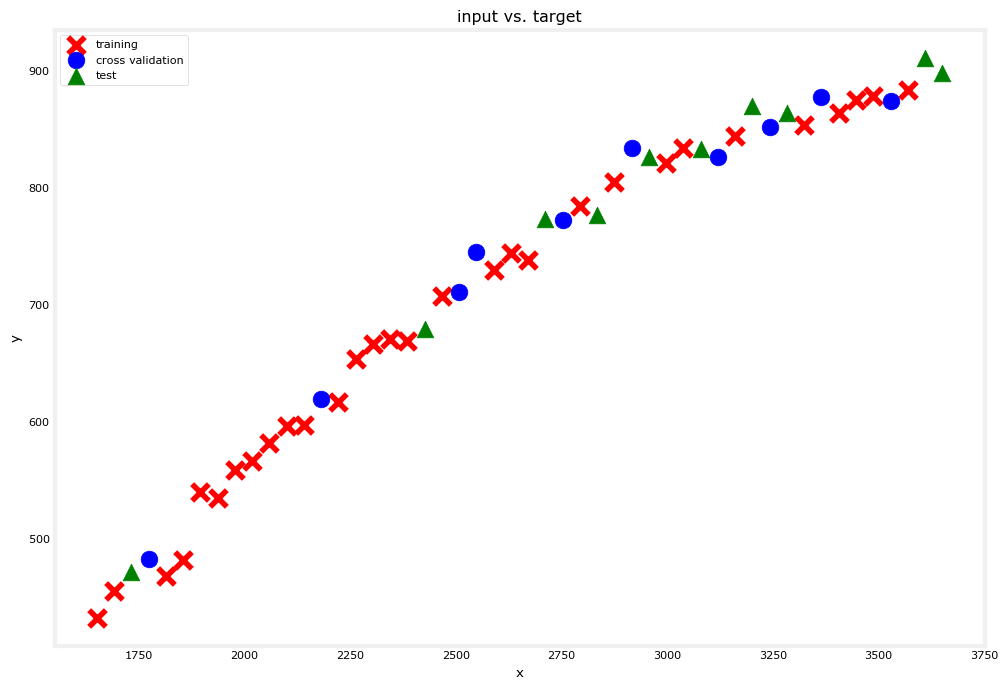

In [9]:
utils.plot_train_cv_test(x_train, y_train, x_cv, y_cv, x_test, y_test, title="input vs. target")

Computed mean of the training set: 2504.06
Computed standard deviation of the training set: 574.85


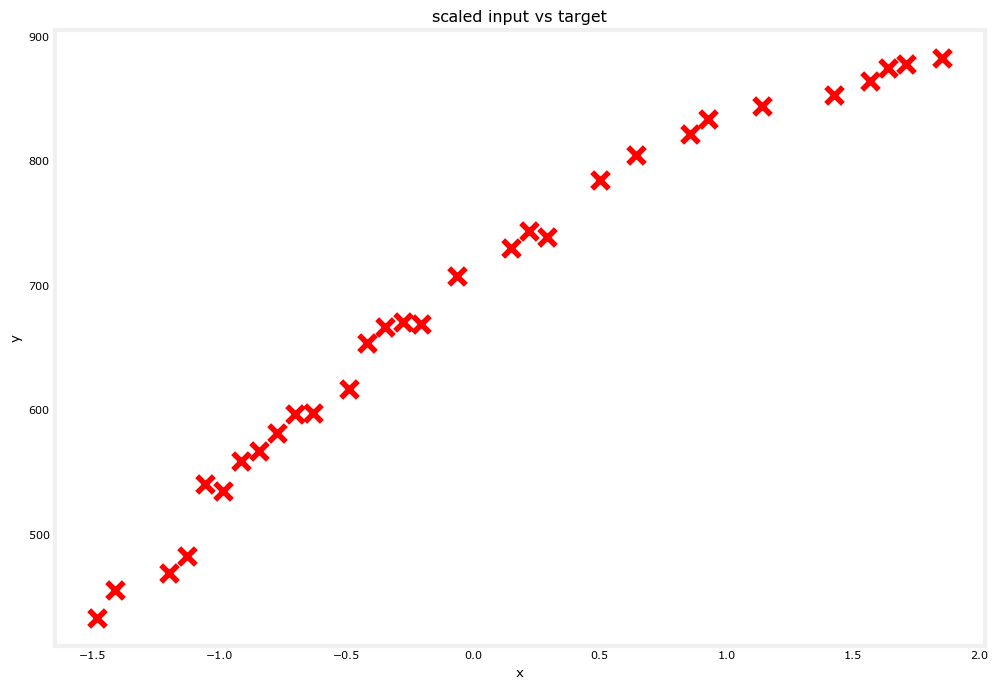

In [10]:
scaler_linear = StandardScaler()

x_train_scaled = scaler_linear.fit_transform(x_train)

print(f"Computed mean of the training set: {scaler_linear.mean_.squeeze():.2f}")
print(f"Computed standard deviation of the training set: {scaler_linear.scale_.squeeze():.2f}")

utils.plot_dataset(x=x_train_scaled, y=y_train, title="scaled input vs target")

In [11]:
linear_model = LinearRegression()
linear_model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
yhat = linear_model.predict(x_train_scaled)
print(f"Training MSE (using sklearn function): {mean_squared_error(y_train, yhat) / 2}")

total_squared_error = 0

for i in range(len(yhat)):
  squared_error_i = (yhat[i] - y_train[i]) ** 2
  total_squared_error += squared_error_i
  
mse = total_squared_error / (2 * len(yhat))

print(f"Training MSE (using for loop): {mse.squeeze():.2f}")

Training MSE (using sklearn function): 406.19374192533155
Training MSE (using for loop): 406.19


In [13]:
x_cv_scaled = scaler_linear.transform(x_cv)

print(f"Mean used to scale the CV set: {scaler_linear.mean_.squeeze():.2f}")
print(f"Standard deviation used to scale the CV set: {scaler_linear.scale_.squeeze():.2f}")

yhat = linear_model.predict(x_cv_scaled)

print(f"Cross validation MSE: {mean_squared_error(y_cv, yhat) / 2}")

Mean used to scale the CV set: 2504.06
Standard deviation used to scale the CV set: 574.85
Cross validation MSE: 551.7789026952216


In [14]:
poly = PolynomialFeatures(degree=2, include_bias=False)

x_train_mapped = poly.fit_transform(x_train)

print(x_train_mapped[:5])

[[3.32e+03 1.11e+07]
 [2.34e+03 5.50e+06]
 [3.49e+03 1.22e+07]
 [2.63e+03 6.92e+06]
 [2.59e+03 6.71e+06]]


In [15]:
scaler_poly = StandardScaler()

x_train_mapped_scaled = scaler_poly.fit_transform(x_train_mapped)

print(x_train_mapped_scaled[:5])

[[ 1.43  1.47]
 [-0.28 -0.36]
 [ 1.71  1.84]
 [ 0.22  0.11]
 [ 0.15  0.04]]


In [16]:
model = LinearRegression()

model.fit(x_train_mapped_scaled, y_train)

yhat = model.predict(x_train_mapped_scaled)
print(f"Training MSE: {mean_squared_error(y_train, yhat) / 2}")

x_cv_mapped = poly.transform(x_cv)
x_cv_mapped_scaled = scaler_poly.transform(x_cv_mapped)

yhat = model.predict(x_cv_mapped_scaled)
print(f"Cross validation MSE: {mean_squared_error(y_cv, yhat) / 2}")


Training MSE: 49.111609334025154
Cross validation MSE: 87.6984121111191


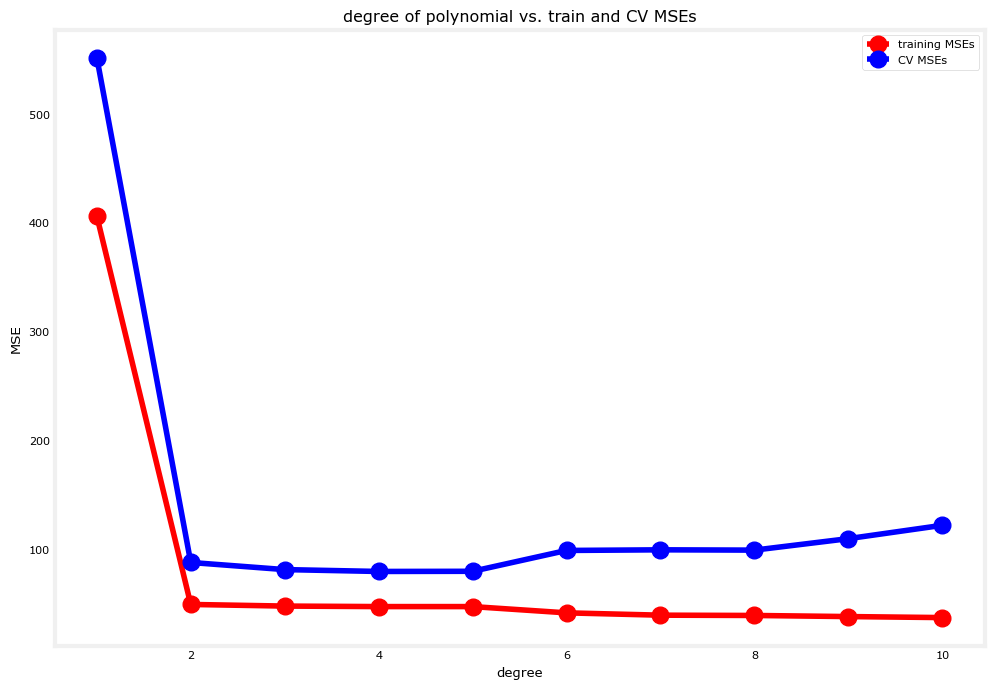

In [17]:
train_mses = []
cv_mses = []
models = []
polys = []
scalers = []

for degree in range(1, 11):
  poly = PolynomialFeatures(degree, include_bias=False)
  x_train_mapped = poly.fit_transform(x_train)
  polys.append(poly)
  
  scaler_poly = StandardScaler()
  x_train_mapped_scaled = scaler_poly.fit_transform(x_train_mapped)
  scalers.append(scaler_poly)
  
  model = LinearRegression()
  model.fit(x_train_mapped_scaled, y_train)
  models.append(model)
  
  yhat = model.predict(x_train_mapped_scaled)
  train_mse = mean_squared_error(y_train, yhat) / 2
  train_mses.append(train_mse)
  
  x_cv_mapped = poly.transform(x_cv)
  x_cv_mapped_scaled = scaler_poly.transform(x_cv_mapped)
  
  yhat = model.predict(x_cv_mapped_scaled)
  cv_mse = mean_squared_error(y_cv, yhat) / 2
  cv_mses.append(cv_mse)
  
degrees = range(1,11)
utils.plot_train_cv_mses(degrees, train_mses, cv_mses, title="degree of polynomial vs. train and CV MSEs")

In [18]:
degree = np.argmin(cv_mses) + 1
print(f"Lowest CV MSE is found in the model with degree {degree} polynomial features.")

Lowest CV MSE is found in the model with degree 4 polynomial features.


In [19]:
x_test_mapped = polys[degree-1].transform(x_test)
x_test_mapped_scaled = scalers[degree-1].transform(x_test_mapped)

yhat = models[degree-1].predict(x_test_mapped_scaled)
test_mse = mean_squared_error(y_test, yhat) / 2

print(f"Training MSE: {train_mses[degree-1]:.2f}")
print(f"Cross validation MSE: {cv_mses[degree-1]:.2f}")
print(f"Test MSE: {test_mse:.2f}")

Training MSE: 47.15
Cross validation MSE: 79.43
Test MSE: 104.63


In [20]:
degree = 1
poly = PolynomialFeatures(degree, include_bias=False)
x_train_mapped = poly.fit_transform(x_train)
x_cv_mapped = poly.transform(x_cv)
x_test_mapped = poly.transform(x_test)

In [21]:
scaler = StandardScaler()
x_train_mapped_scaled = scaler.fit_transform(x_train_mapped)
x_cv_mapped_scaled = scaler.transform(x_cv_mapped)
x_test_mapped_scaled = scaler.transform(x_test_mapped)

In [ ]:
nn_train_mses = []
nn_cv_mses = []
nn_models = utils.build_models()

for model in nn_models:
  model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1)
  )